## rSVD versus rSVDAdjoint

In this notebook I compare the computational time of the rSVD algorithms versus using the rSVDAdjoint algorithm.
The rSVDAdjoint algorithm approximates $K^* \approx K^*_k = \tilde U \tilde \Sigma \tilde V^T$, and then $K$ can be approximated via 
$$
K \approx M_\partial^{-1} (K_k^*)^T M = M_\partial^{-1} \tilde V \tilde \Sigma \tilde U^T M
$$
To recover the SVD of $K$, let $F = M_\partial^{-1} \tilde V$ and $G = M \tilde U^T$, meaning $K \approx F \tilde \Sigma G^T$. Orthogonalization of $F$ and $G$ is done by QR factorization, $Q_F R_F = F$ and $Q_G R_G = G$, so that $K \approx Q_F (R_F \tilde \Sigma R_G^T) Q_G$, and the SVD $R_F \tilde \Sigma R_G^T = \hat U \Sigma \hat V^T$ gives $K \approx (Q_F \hat U) \Sigma (\hat V^T Q_G^T)$, with $U = Q_F \hat U$ and $V = Q_G \hat V$ yielding the SVD $K \approx U \Sigma V^T$.

---

In [35]:
import numpy as np
import pandas as pd
from time import time
from algorithms.rsvd_solvers import MatrixFreeRSVD, MatrixFreeRSVDAdjoint
from fenics import FunctionSpace, UnitSquareMesh, plot, Function
from utils.problem_setup import TestProblemsSetup
from utils.solvers import fast_svd_solver
from utils.utils import progress_bar, disk_cache
import matplotlib.pyplot as plt


In [ ]:
problems = TestProblemsSetup(n=64).get_test_problems()
p = problems['I']

f_hat = Function(p['V_h'])

In [40]:
@disk_cache('../../results/rsvd_vs_rsvdAdjoint')
def experiment(N_range, k, repeat):

    record = []
    n_steps, step = len(N_range) * repeat, 1
    for N in N_range:
        n = round(np.sqrt(N))
        V_h = FunctionSpace(UnitSquareMesh(n, n), 'CG', 1)

        for _ in range(repeat):
            progress_bar(step, n_steps, end_text=f' [{N=:,}]')
            step += 1
            
            result = {'N': N}

            # Approximate K
            t = time()
            rsvd = MatrixFreeRSVD(V_h)
            rsvd.solve(k=k)
            result['rsvd'] = time() - t

            # Approximate K*
            t = time()
            rsvd_adj = MatrixFreeRSVDAdjoint(V_h)
            rsvd_adj.solve(k=k)
            result['rsvd_adj'] = time() - t 

            # Recover K from K*
            t = time()
            rsvd_adj.recover_K()
            result['recovery'] = time() - t

            record.append(result)

    return pd.DataFrame(record)


In [66]:
N_range = np.linspace(1_000, 300_000, 21, dtype=int)
repeat = 30
params = [
    {'N_range': N_range, 'k': 10, 'repeat': repeat},
    {'N_range': N_range, 'k': 25, 'repeat': repeat},
    {'N_range': N_range, 'k': 50, 'repeat': repeat},
]
results = [{'params': p, 'df': experiment(**p)} for p in params]

[##############################] 630/630 [N=300,000]
[##############################] 630/630 [N=300,000]
[##############################] 630/630 [N=300,000]


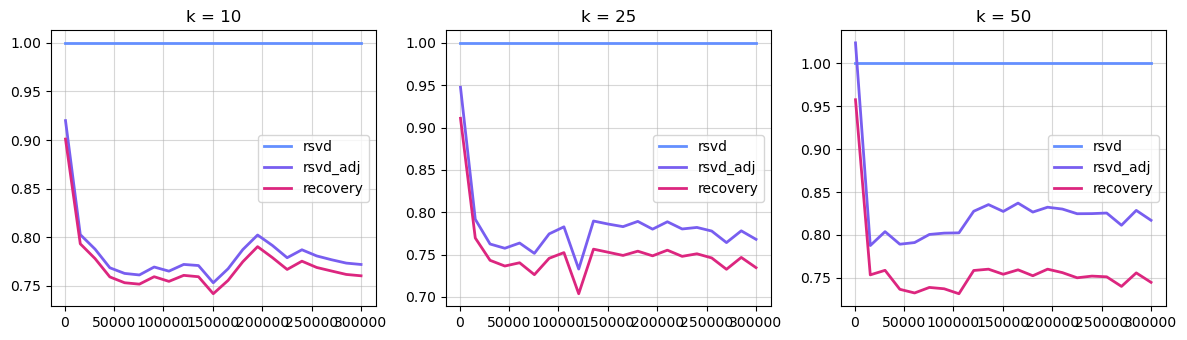

In [75]:
from utils.colors import C3
cols = ['rsvd', 'rsvd_adj']

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=False)

for ax, result in zip(axes.T.flat, results):
    params = result['params']
    df = result['df'].groupby('N').agg('median').reset_index()
    
    for i, col in enumerate(cols):
        ax.plot(df.N, df['rsvd'] / df[col], c=C3[i], lw=2, label=col)
    ax.plot(df.N, df['rsvd'] / (df['rsvd_adj'] + df['recovery']), c=C3[2], lw=2, label='recovery')
    
    ax.set_title(f"k = {params['k']}")
    ax.legend()
    ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()